In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('diabetes.csv')

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
invalid_cols=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

df[invalid_cols]=df[invalid_cols].replace(0,np.nan)

In [6]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## Impute

### If |skewness| > 0.5 → use Median (robust to outliers). If |skewness| ≤ 0.5 → use Mean (captures the true average of a symmetric distribution).

<Axes: xlabel='Glucose', ylabel='Density'>

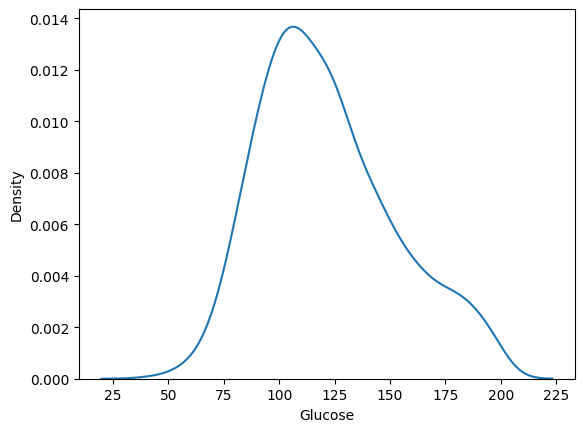

In [7]:
sns.kdeplot(data=df,x='Glucose')

<Axes: xlabel='BloodPressure', ylabel='Density'>

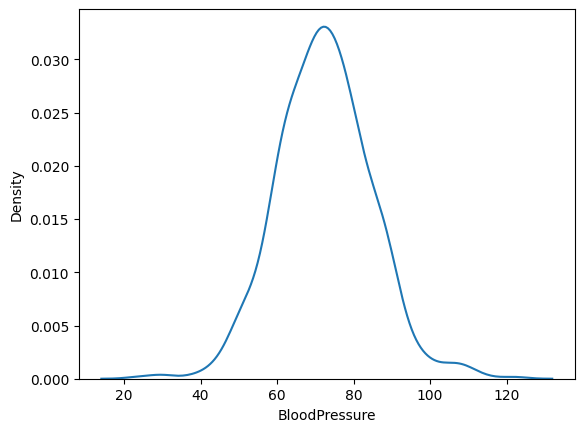

In [8]:
sns.kdeplot(data=df,x='BloodPressure')

<Axes: xlabel='SkinThickness', ylabel='Density'>

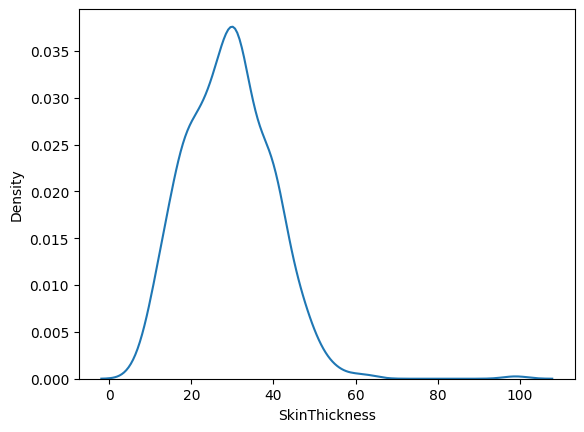

In [9]:
sns.kdeplot(data=df,x='SkinThickness')

<Axes: xlabel='Insulin', ylabel='Density'>

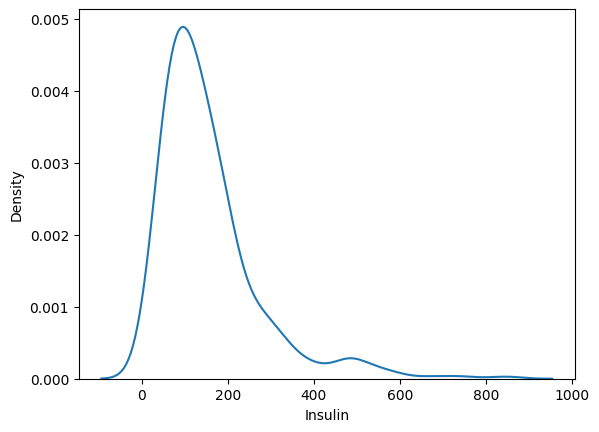

In [10]:
sns.kdeplot(data=df,x='Insulin')

<Axes: xlabel='BMI', ylabel='Density'>

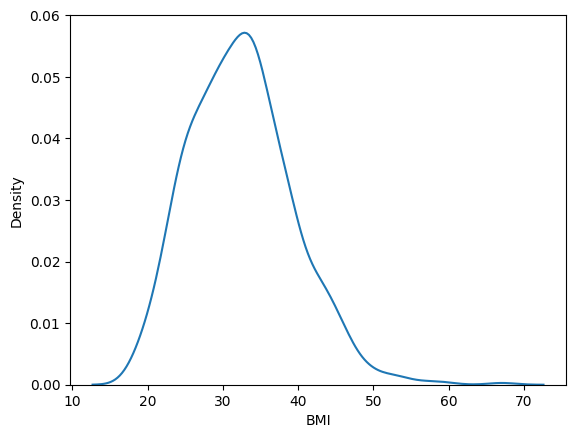

In [11]:
sns.kdeplot(data=df,x='BMI')

In [12]:
print(df['Glucose'].skew()) #median impute
print(df['BloodPressure'].skew()) # mean impute
print(df['SkinThickness'].skew()) #median impute
print(df['Insulin'].skew()) #median impute
print(df['BMI'].skew()) #median impute


0.5309885349396285
0.13415273171959252
0.690619013984192
2.166463843812443
0.5939697505712673


In [13]:
df['Glucose']=df['Glucose'].fillna(df['Glucose'].median())
df['BloodPressure']=df['BloodPressure'].fillna(df['BloodPressure'].mean())
df['SkinThickness']=df['SkinThickness'].fillna(df['SkinThickness'].median())
df['Insulin']=df['Insulin'].fillna(df['Insulin'].median())
df['BMI']=df['BMI'].fillna(df['BMI'].median())

In [14]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [16]:
def age_group(age):
  if age<30:
    return 'Young'
  elif age<=50:
    return 'Adult'
  else:
    return 'Senior'


df['Age_Group']=df['Age'].apply(age_group)


In [17]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age_Group
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,Adult
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,Adult
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,Adult
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Young
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,Adult
...,...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0,Senior
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0,Young
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0,Adult
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1,Adult


In [20]:
from sklearn.preprocessing import OrdinalEncoder

age_enc=OrdinalEncoder(categories=[['Young','Adult','Senior']])

df['Age_encoded']=age_enc.fit_transform(df[['Age_Group']]).ravel()

In [21]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age_Group,Age_encoded
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,Adult,1.0
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,Adult,1.0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,Adult,1.0
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Young,0.0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,Adult,1.0
...,...,...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0,Senior,2.0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0,Young,0.0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0,Adult,1.0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1,Adult,1.0
